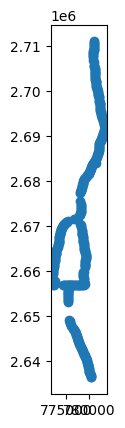

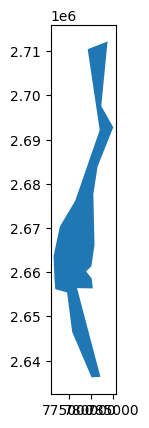

In [2]:
import numpy as np
import geopandas as gpd
from scipy.spatial import cKDTree
import rasterio
from rasterio.transform import from_origin
from shapely.geometry import Polygon
from shapely.ops import unary_union
import matplotlib.pyplot as plt    


crs = 'EPSG:32645'
output_path = 'swot_processing'
# Load the shapefile of roi with geopandas

pth_clip_extent = 'swot_processing/toClipSWOTData/toClipSWOTData.shp'
clip_extent = gpd.read_file(pth_clip_extent).to_crs('EPSG:32645')

# Path of swot data shapefile
pth_swot = 'Node_011_189_AS_20240221/SWOT_L2_HR_RiverSP_Node_011_189_AS_20240221T144834_20240221T144845_PIC0_01.shp'

centreline_points = gpd.read_file(filename= pth_swot,bbox= clip_extent, where = "node_q='1'").to_crs(crs)

centreline_points = centreline_points.clip(clip_extent)

centreline_points.to_file('swot_processing/fltrd_Jamuna_swot_20240221.shp')
# centreline_points.plot()
# print('old crs',centreline_points.crs)
# centreline_points = centreline_points.to_crs('EPSG:32645')
centreline_points.plot()
clip_extent.plot()
# print('new crs',centreline_points.crs)

# Calculate the bounds of the points to define the extent
bounds = centreline_points.total_bounds  # returns (minx, miny, maxx, maxy)
buffer = 8000
extent_polygon = Polygon([
    (bounds[0]-buffer, bounds[1]-buffer),
    (bounds[2]+buffer, bounds[1]-buffer),
    (bounds[2]+buffer, bounds[3]+buffer),
    (bounds[0]-buffer, bounds[3]+buffer)
])

aoi = gpd.GeoDataFrame(geometry=[extent_polygon],crs = 'EPSG:32645')
aoi.to_file('swot_processing/AOI.shp')

In [13]:
pixel_size = 30

width = int((extent_polygon.bounds[2]-extent_polygon.bounds[0])/pixel_size)
height = int((extent_polygon.bounds[3]-extent_polygon.bounds[1])/pixel_size)

width,height

transform = from_origin(west=extent_polygon.bounds[0], north=extent_polygon.bounds[3], xsize= pixel_size,ysize=pixel_size)



In [14]:
raster_array = np.zeros((height, width), dtype='float32')


In [15]:
x_coords = np.arange(extent_polygon.bounds[0], extent_polygon.bounds[2],pixel_size) + (pixel_size/2)
y_coords = np.arange(extent_polygon.bounds[1], extent_polygon.bounds[3],pixel_size) + (pixel_size/2)
y_coords = y_coords[::-1]
xx,yy = np.meshgrid(x_coords,y_coords)

points_raster = np.vstack((xx.ravel(), yy.ravel())).T
points_raster

array([[ 764094.06308461, 2719044.99615933],
       [ 764124.06308461, 2719044.99615933],
       [ 764154.06308461, 2719044.99615933],
       ...,
       [ 791424.06308461, 2628354.99615933],
       [ 791454.06308461, 2628354.99615933],
       [ 791484.06308461, 2628354.99615933]])

In [6]:
points_centreline = np.array(list(zip(centreline_points.geometry.x, centreline_points.geometry.y)))
wse_centreline = centreline_points['wse'].to_numpy()
wse_centreline

array([ 2.21741,  2.2508 ,  2.22376,  2.25132,  2.27162,  2.32137,
        2.53199,  2.42868,  2.51955,  3.40648,  3.11232,  3.13492,
        3.04857,  2.54826,  2.79825,  3.05555,  2.99152,  4.55992,
        7.42446,  8.20934,  7.9677 ,  8.58791,  8.95903,  9.20477,
       10.09723,  2.19086,  2.22741,  2.96113,  3.30409,  3.1953 ,
        3.95637,  2.95285,  3.14997,  3.13795,  3.18335,  4.01011,
        4.63041,  4.69497,  3.87899,  3.53799,  3.52029,  3.81365,
        3.99781,  2.93262,  3.07054,  3.20161,  2.89585,  2.87972,
        2.96745,  2.89507,  3.07597,  2.96651,  3.05313,  2.96122,
        2.95158,  2.95799,  2.85558,  2.98513,  2.96668,  2.97858,
        3.07114,  2.90471,  3.06195,  3.35472,  2.92003,  2.98702,
        2.9357 ,  6.5142 ,  5.98406,  2.65465,  2.82857,  3.44822,
        3.47204,  3.86545,  5.72355,  3.8984 ,  2.67235,  3.42319,
        3.09649,  3.22864,  2.85213,  3.1907 ,  2.99511,  2.95011,
        3.00443,  3.7077 ,  2.97664,  3.03749,  4.6058 ,  4.19

In [7]:
tree = cKDTree(points_centreline)
tree

In [8]:
distances, indices = tree.query(points_raster)
distances, indices

(array([18882.13824146, 18854.97190178, 18827.81416585, ...,
        13465.65706369, 13489.82508845, 13514.01648945]),
 array([386, 386, 386, ...,  95,  95,  95], dtype=int64))

In [9]:
raster_array_flat = wse_centreline[indices]
raster_array_flat

array([6.32241, 6.32241, 6.32241, ..., 1.99967, 1.99967, 1.99967])

In [10]:
raster_array = raster_array_flat.reshape(yy.shape)
raster_array

array([[6.32241, 6.32241, 6.32241, ..., 6.32241, 6.32241, 6.32241],
       [6.32241, 6.32241, 6.32241, ..., 6.32241, 6.32241, 6.32241],
       [6.32241, 6.32241, 6.32241, ..., 6.32241, 6.32241, 6.32241],
       ...,
       [1.99967, 1.99967, 1.99967, ..., 1.99967, 1.99967, 1.99967],
       [1.99967, 1.99967, 1.99967, ..., 1.99967, 1.99967, 1.99967],
       [1.99967, 1.99967, 1.99967, ..., 1.99967, 1.99967, 1.99967]])

In [11]:
with rasterio.open(fp= output_path+'/nn_wse_20240313_v2.tif',
                   mode='w',driver='GTiff',height= height, 
                   width= width, count= 1, dtype='float32',crs=crs,
                   transform=transform) as dst:
                        data = raster_array#np.zeros((height, width), dtype='float32')
    
    # Write the array to the raster
                        dst.write(data, 1)
 
                   


<Axes: >

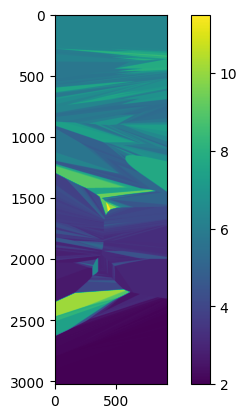

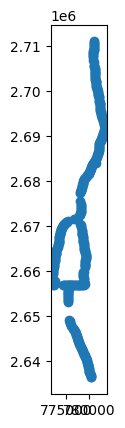

In [12]:
plt.imshow(raster_array, cmap= 'viridis')
plt.colorbar()
centreline_points.plot()